# v01
In v01 I work with domains more carefully

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib ipympl

import os
from glob import glob

import h5py
import matplotlib.collections
import time

In [2]:
def extent_from_x(xhighres):
    dxhighres = [x[1] - x[0] for x in xhighres]

    extenthighres0 = (xhighres[-1][0]-dxhighres[-1]/2, xhighres[-1][-1]+dxhighres[-1]/2, xhighres[-2][-1]+dxhighres[-2]/2, xhighres[-2][0]-dxhighres[-2]/2)
    extenthighres1 = (xhighres[-1][0]-dxhighres[-1]/2, xhighres[-1][-1]+dxhighres[-1]/2, xhighres[-3][-1]+dxhighres[-3]/2, xhighres[-3][0]-dxhighres[-3]/2)
    extenthighres2 = (xhighres[-2][0]-dxhighres[-2]/2, xhighres[-2][-1]+dxhighres[-2]/2, xhighres[-3][-1]+dxhighres[-3]/2, xhighres[-3][0]-dxhighres[-3]/2)

    return extenthighres0,extenthighres1,extenthighres2

# goals

Load and display bounding boxes for 1 sagital, 1 coronal, and one transverse whole slice.

Where they intersect I want to view a 3D volume with bounding boxes, loaded from your output data.

Potentially, I would want to reconstruct the 3D volume from the 2D slices.

# First chose one 3D cube and find the slices that go right though the middle

The directory below has npy files.

Each npy file has an ijk index.

2,1,3 is reasonable.

Since the cube is at low resolution this starts at

i: 2 * 256 to 3 * 256

j: 1 * 256 to 2 * 256

k: 3 * 256 to 4 * 256


Because of 4x downsampling, the size is actually 1024 (at native resolution). (recall we start with 2x updsampling, and the network does 8x downsampling)

# note
Initialized from

view_data_and_try_to_fix_shift_v01

In [2]:
# output file naming convention like this
# i0000_j0000_k0000_d256_Ex_488_Em_525.npy

In [3]:
threeDcubedir_for_outputs = '/home/dtward/mounts/bmaproot/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_3D_outputs_v02_'
d = 256
out_suffix = f'd{d}_Ex_488_Em_525.npy'

In [4]:
# starting location for this cube
i = 2
j = 3
k = 5

# walk through the features
The first 3 axes are slice row col

The fourth axis has 10 numbers.

slicemin, slicemax

rowmin, rowmax,

colmin, colmax

Then confidence (normalized)

Followed by 3 class probabilities (unnormalized)

In [5]:
# if i = 0, j = 0, k = 0, the first coordinate of the cube is not 0, it is 1.5
(0+1+2+3)/4

1.5

# (0) Compute several parameters before processing + Generate some validation figures

In [24]:
# I need the spatial coordinates of the datacube
# n is the size (256)
i,j,k = 0,0,0
ndatacube = np.array((d,d,d)) 

# x0 is the location of the first pixel (within the high res volume)
x0datacube = np.array([0,0,0]) # initialize 
x0datacube = np.array([1.5,1.5,1.5]) + np.array([i,j,k])*d*4 # (up by 2 down by 8)

# get the coordinates of each voxel
xdatacube = [np.arange(n)*4+o for n,o in zip(ndatacube,x0datacube)]

# get the voxel size
ddatacube = np.array([4,4,4])

In [25]:
# for drawing we need extents
# extent for viewing with constant slice (this is transverse)
extentdatacube0 = (xdatacube[-1][0]-ddatacube[-1]/2, xdatacube[-1][-1]+ddatacube[-1]/2, xdatacube[-2][-1]+ddatacube[-2]/2, xdatacube[-2][0]-ddatacube[-2]/2)

# extent for viewing with constant row (this is coronal)
extentdatacube1 = (xdatacube[-1][0]-ddatacube[-1]/2, xdatacube[-1][-1]+ddatacube[-1]/2, xdatacube[-3][-1]+ddatacube[-3]/2, xdatacube[-3][0]-ddatacube[-3]/2)

# extent for viewing with constant col (this is sagittal)
extentdatacube2 = (xdatacube[-2][0]-ddatacube[-2]/2, xdatacube[-2][-1]+ddatacube[-2]/2, xdatacube[-3][-1]+ddatacube[-3]/2, xdatacube[-3][0]-ddatacube[-3]/2)

## (0.1) Compute middle indeces along the slice, row, col dimensions

For visualization only

In [26]:
# it doesn't have a middle, so the middle coordinate is not a round number, so we convert to an int
# I will want to load these slices for display
m0 = int( np.round( xdatacube[0][len(xdatacube[0])//2]) )
m1 = int( np.round( xdatacube[1][len(xdatacube[1])//2]) )
m2 = int( np.round( xdatacube[2][len(xdatacube[2])//2]) ) 
print(m0,m1,m2)

# we can enumerate the first and last pixel in the region covered by the datacube
# this is for cutting out parts for faster processing
start0 = xdatacube[0][0]
start1 = xdatacube[1][0]
start2 = xdatacube[2][0]

end0 = xdatacube[0][-1]
end1 = xdatacube[1][-1]
end2 = xdatacube[2][-1]
print(f'[{start0},{end0}],[{start1},{end1}],[{start2},{end2}]')

514 514 514
[1.5,1021.5],[1.5,1021.5],[1.5,1021.5]


## (0.2) Extract these middle slices from the full res data, for visualizatoin

In [29]:
raw_image_file_first_two_views = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
vol01 = h5py.File(raw_image_file_first_two_views)
nhighres = vol01['stack'].shape
xhighres = [np.arange(n) for n in nhighres]

raw_image_file_third_view = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_full_sag.h5'
vol2 = h5py.File(raw_image_file_third_view)
nhighres = vol2['stack'].shape

In [23]:
# get an extent for drawing
extenthighres0,extenthighres1,extenthighres2 = extent_from_x(xhighres)    

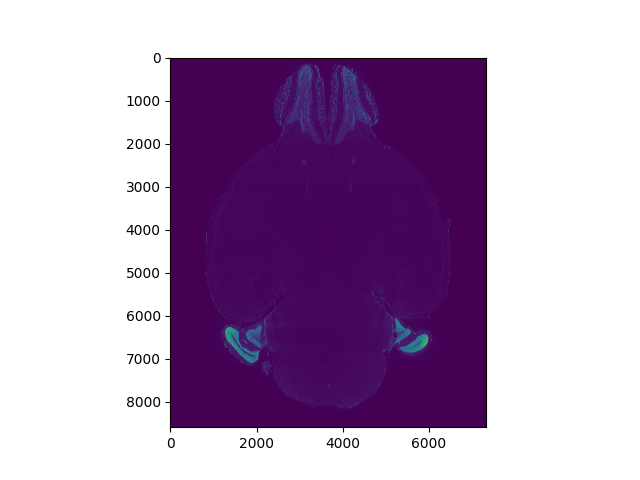

In [27]:
# chose the middle slice
Islice = vol01['stack'][m0]
Irow   = vol01['stack'][:,m1]
Icol = vol2['stack'][:,:,m2]

fig,ax = plt.subplots(1,3)
ax[0].imshow(Islice,extent=extenthighres0)
ax[1].imshow(Irow,extent=extenthighres1)
ax[2].imshow(Icol,extent=extenthighres2)

In [30]:
vol01.close()
vol2.close()

## (0.3) Draw the rectangle that corresponds to the 3D cube

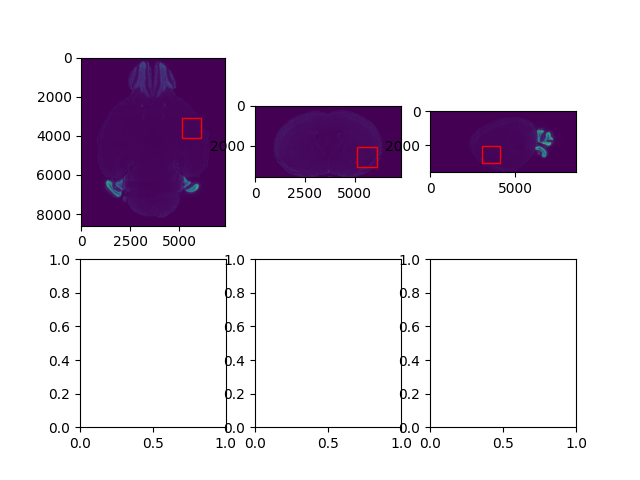

In [38]:
downshow = 8

extenthighres0d,extenthighres1d,extenthighres2d = extent_from_x([x[::downshow] for x in xhighres])

fig,ax = plt.subplots(2,3)
ax[0,0].imshow(Islice[::downshow,::downshow],extent=extenthighres0d) 
rect0 = plt.Rectangle((start2,start1), (end2-start2),(end1-start1), edgecolor='r', facecolor='none')
ax[0,0].add_patch(rect0)

ax[0,1].imshow(Irow[::downshow,::downshow],extent=extenthighres1d)
rect1 = plt.Rectangle((start2,start0), (end2-start2),(end0-start0), edgecolor='r', facecolor='none')
ax[0,1].add_patch(rect1)

ax[0,2].imshow(Icol[::downshow,::downshow],extent=extenthighres2d)
rect2 = plt.Rectangle((start1,start0), (end1-start1),(end0-start0), edgecolor='r', facecolor='none')
ax[0,2].add_patch(rect2)

#ax[1,0].imshow(datacube[datacube.shape[0]//2,...,6],vmin=0,vmax=1)
#ax[1,1].imshow(datacube[:,datacube.shape[1]//2,...,6],vmin=0,vmax=1)
#ax[1,2].imshow(datacube[:,:,datacube.shape[2]//2,...,6],vmin=0,vmax=1)

## (0.4) Load the 2D detections for these slices

These are 2D ones, before any stitching.  For display we load the middle slice.  Later we'll load all the slices.

For display, we'll compare the 3D cubes to these single slice images.  They should be roughly the same.

In [27]:
# in this directory there are lots of slices
# note the order here, it is xmin,ymin, xmax,ymax
ax0outputdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax0'
ax1outputdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax1'
ax2outputdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax2'

In [30]:
# Load the middle slice along each dimension (Each slice contains bbox info at every pixel)
ax0files = glob(join(ax0outputdir,'*.npy'))
ax0files.sort()
ax0detects = np.load(ax0files[m0]) # this is the middle slice

ax1files = glob(join(ax1outputdir,'*.npy'))
ax1files.sort()
ax1detects = np.load(ax1files[m1])

ax2files = glob(join(ax2outputdir,'*.npy'))
ax2files.sort()
ax2detects = np.load(ax2files[m2])

print(ax0detects.shape,nhighres) # note downsampling by 4

(2148, 1832, 8) (3600, 8587, 7321)


In [55]:
# TODO: potentially come back later and deal with this minor issue
# note the outputs were created by first upsampling by 2
# then downsampling by 8
# for a net downsampling of 4
# the outputs were created by taking the displacements
# and adding the pixel position of the output times the stride
# that was to give coordinates in the upsampled space
# then they were divided by 2
#
# okay, but after upsampling
# the pixel with coordinate 0, that spans from -0.5 to 0.5
# becomes two pixels
# the first spans -0.5 to 0, the second spans 0 to 0.5
# so the coordinates of the first two pixels are -0.25, and 0.25
# 
# now when we downsample by 8
# the average coordinate is 1.5, okay that's what I was using in this notebook
print( np.mean( np.arange(8)*0.5 - 0.25 ) )
# during post processing we added x = torch.arange(out.shape[-1])*stride + (stride-1)/2
# but stride was 8, not 4
# we divided by 2 later
print((8-1)/2)
print((8-1)/2/2)
# so the location of the first pixel SHOULD HAVE BEEN 1.5
# but instead it is 1.75.  This is a pretty minor mistake

1.5
3.5
1.75


In [56]:
# get the pixel locations, and extents for display, in each of the three views
ax0x1 = np.arange(ax0detects.shape[0])*4 + np.mean( np.array([0,1,2,3]) )
ax0x2 = np.arange(ax0detects.shape[1])*4 + np.mean( np.array([0,1,2,3]) )
ax0x = [ax0x1,ax0x2]
extentax00,extentax01,extentax02 = extent_from_x([[0,1],ax0x1,ax0x2])

ax1x0 = np.arange(ax1detects.shape[0])*4 + np.mean( np.array([0,1,2,3]) )
ax1x2 = np.arange(ax1detects.shape[1])*4 + np.mean( np.array([0,1,2,3]) )
ax1x = [ax1x0,ax1x2]
extentax10,extentax11,extentax12 = extent_from_x([ax1x0,[0,1],ax1x2])

ax2x0 = np.arange(ax2detects.shape[0])*4 + np.mean( np.array([0,1,2,3]) )
ax2x1 = np.arange(ax2detects.shape[1])*4 + np.mean( np.array([0,1,2,3]) )
ax2x = [ax2x0,ax2x1]
extentax20,extentax21,extentax22 = extent_from_x([ax2x0,ax2x1,[0,1],])

(3073.5, 4093.5)

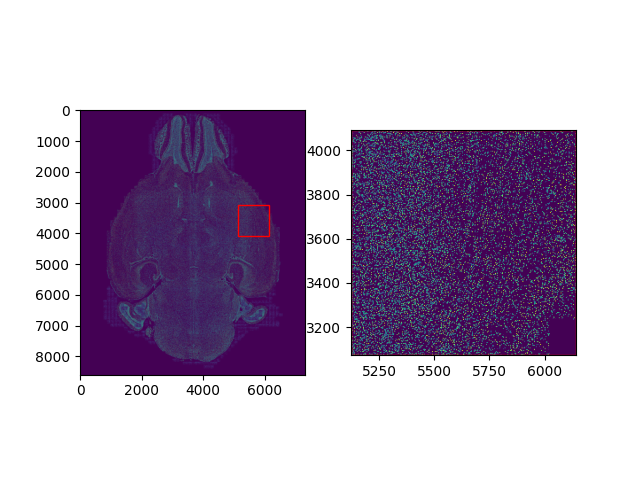

In [61]:
# Draw the confidence of every bbox in the slice
fig,ax_ = plt.subplots(1,2)
ax = ax_[0]
ax0p =  ax0detects[...,4] 
ax.imshow(ax0p,vmin=0,vmax=1,extent=extentax00)
rect0 = plt.Rectangle((start2,start1), (end2-start2),(end1-start1), edgecolor='r', facecolor='none')
ax.add_patch(rect0)

ax = ax_[1]
ax.imshow(ax0p,vmin=0,vmax=1,extent=extentax00)
rect0 = plt.Rectangle((start2,start1), (end2-start2),(end1-start1), edgecolor='r', facecolor='none')
ax.add_patch(rect0)
ax.set_xlim(start2,end2)
ax.set_ylim(start1,end1)

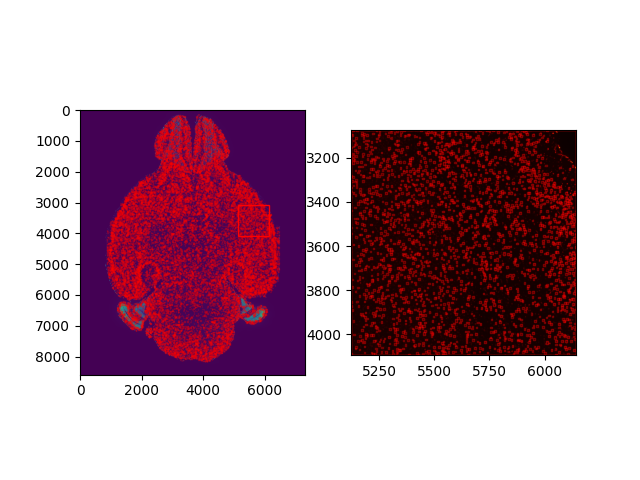

In [62]:
# now show the image and bounding boxes
inds = ax0p>0.75
# note the order here, it is xmin,ymin, xmax,ymax
rectdata = np.stack( 
        (
            np.stack((ax0detects[inds,0].ravel(), ax0detects[inds,1].ravel()),-1), 
            np.stack((ax0detects[inds,0].ravel(), ax0detects[inds,3].ravel()),-1),
            np.stack((ax0detects[inds,2].ravel(), ax0detects[inds,3].ravel()),-1), 
            np.stack((ax0detects[inds,2].ravel(), ax0detects[inds,1].ravel()),-1),             
        ),
        1)
edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0
edgecolor[:,-1] = ax0detects[inds,4]*0.5
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=ax0detects[inds,4].ravel(),
)


# draw it
fig,ax_ = plt.subplots(1,2)
ax = ax_[0]
ax.imshow(ax0p,vmin=0,vmax=1,extent=extentax00)
ax.imshow(Islice,vmin=0,vmax=65535,extent=extenthighres0)
rect0 = plt.Rectangle((start2,start1), (end2-start2),(end1-start1), edgecolor='r', facecolor='none')
ax.add_patch(rect0)
ax.add_collection(rects)


rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=ax0detects[inds,4].ravel(),
)
ax = ax_[1]
ax.imshow(ax0p,vmin=0,vmax=1,extent=extentax00,cmap='gray')
ax.imshow(Islice,vmin=0,vmax=65535/2,extent=extenthighres0,alpha=1,cmap='hot')
rect0 = plt.Rectangle((start2,start1), (end2-start2),(end1-start1), edgecolor='r', facecolor='none')
ax.add_patch(rect0)
ax.set_xlim(start2,end2)
ax.set_ylim(end1,start1)
ax.add_collection(rects)

# (1) The Big Loop

In [3]:
d = 256 # The desired output shape for each cube
down_factor = 4 # The factor by which the size of the whole dataset shrunk during processing (2x upsampling AND 8x 'downsampling' => 4x downsampling)
outdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_3D_outputs_v03'

# Transverse / Axial / Horizontal slices - [DV, AP, LR]
indir0 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax0'
data0 = np.load(os.path.join(indir0,os.listdir(indir0)[0]))
shape0 = data0.shape

# Coronal slices - [AP, DV, LR]
indir1 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax1'
data1 = np.load(os.path.join(indir1,os.listdir(indir1)[0]))
shape1 = data1.shape

# Sagittal slices - [LR, DV, AP]
indir2 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax2'
data2 = np.load(os.path.join(indir2,os.listdir(indir2)[0]))
shape2 = data2.shape

final_shape = np.array([shape1[0], shape0[0], shape0[1]]) # [DV, AP, LR]

n_cube_i = int(np.ceil(final_shape[0] / d)) # Num complete cubes along AP axis (Transverse)
n_cube_j = int(np.ceil(final_shape[1] / d)) # Num complete cubes along DV axis (Coronal)
n_cube_k = int(np.ceil(final_shape[2] / d)) # Num complete cubes along LR axis (Sagittal)
print(f'Total Cubes Shape: ({n_cube_i}, {n_cube_j}, {n_cube_k})')

next_i, next_j, next_k = 3,2,1

for i in np.arange(n_cube_i): # NOTE: Originally, included a (+1) to each np.arange(...) to include edge case cubes
    
    if i < next_i:
        continue
        
    for j in np.arange(n_cube_j):
        
        if j < next_j and i <= next_i:
            continue
            
        for k in np.arange(n_cube_k):

            if k < next_k and i <= next_i and j <= next_j:
                continue

            print(f'Starting cube ({i},{j},{k}) . . .')
            start_time = time.time()

            # Determine if cube is an edge case
            isEdge_i = True if i == n_cube_i - 1 else False
            isEdge_j = True if j == n_cube_j - 1 else False
            isEdge_k = True if k == n_cube_k - 1 else False
            print(f'Edge? - {isEdge_i} {isEdge_j} {isEdge_k}')

            # The spatial coordinates of the datacube
            ndatacube = np.array((d,d,d)) 
            
            # x0 is the location of the first pixel (within the high res volume)
            x0datacube = np.array([0,0,0]) # initialize 
            x0datacube = np.array([1.5,1.5,1.5]) + np.array([i,j,k])*d*down_factor # ([]*256*4 - up by 2 down by 8)
            
            # get the coordinates of each voxel
            xdatacube = [np.arange(n)*down_factor+o for n,o in zip(ndatacube,x0datacube)]
            
            # get the voxel size
            ddatacube = np.array([down_factor,down_factor,down_factor])
            
            # Get start and end indeces for coordinate systems
            start0 = xdatacube[0][0]
            start1 = xdatacube[1][0]
            start2 = xdatacube[2][0]
            end0 = xdatacube[0][-1] if isEdge_i else xdatacube[0][-1]
            end1 = xdatacube[1][-1] if isEdge_j else xdatacube[1][-1]
            end2 = xdatacube[2][-1] if isEdge_k else xdatacube[2][-1]

            # Load the detections from each directory
            # NOTE: Order is xmin,ymin,xmax,ymax
            
            # Generate a list of fnames for all the slices in each dir (Each slice contains bbox info at every pixel)
            ax0files = glob(os.path.join(indir0,'*.npy'))
            ax0files.sort()
            ax0detects = np.load(ax0files[0]) # Load the first slice for shape info
            
            ax1files = glob(os.path.join(indir1,'*.npy'))
            ax1files.sort()
            ax1detects = np.load(ax1files[0]) # Load the first slice for shape info
            
            ax2files = glob(os.path.join(indir2,'*.npy'))
            ax2files.sort()
            ax2detects = np.load(ax2files[0]) # Load the first slice for shape info

            # (07/16/26) Added if/else logic to address edge case
            start0i = np.floor(start0).astype(int)-1
            start1i = np.floor(start1).astype(int)-1
            start2i = np.floor(start2).astype(int)-1
            end0i = len(ax0files)-1 if isEdge_i else np.ceil(end0).astype(int)
            end1i = len(ax1files)-1 if isEdge_j else np.ceil(end1).astype(int)
            end2i = len(ax2files)-1 if isEdge_k else np.ceil(end2).astype(int)

            print(f'Extent: [{start0},{end0}],[{start1},{end1}],[{start2},{end2}]')
            print(f'Extent_i:  [{start0i},{end0i}],[{start1i},{end1i}],[{start2i},{end2i}]')

            # get the pixel locations, and extents for display, in each of the three views
            ax0x1 = np.arange(ax0detects.shape[0])*down_factor + np.mean( np.array([0,1,2,3]) )
            ax0x2 = np.arange(ax0detects.shape[1])*down_factor + np.mean( np.array([0,1,2,3]) )
            ax0x = [ax0x1,ax0x2]
            extentax00,extentax01,extentax02 = extent_from_x([[0,1],ax0x1,ax0x2])
            
            ax1x0 = np.arange(ax1detects.shape[0])*down_factor + np.mean( np.array([0,1,2,3]) )
            ax1x2 = np.arange(ax1detects.shape[1])*down_factor + np.mean( np.array([0,1,2,3]) )
            ax1x = [ax1x0,ax1x2]
            extentax10,extentax11,extentax12 = extent_from_x([ax1x0,[0,1],ax1x2])
            
            ax2x0 = np.arange(ax2detects.shape[0])*down_factor + np.mean( np.array([0,1,2,3]) )
            ax2x1 = np.arange(ax2detects.shape[1])*down_factor + np.mean( np.array([0,1,2,3]) )
            ax2x = [ax2x0,ax2x1]
            extentax20,extentax21,extentax22 = extent_from_x([ax2x0,ax2x1,[0,1],])
            
            print('Finished initializing global variables and data structures . . .')
            
            # Start by loading the transverse slices + Compress data via downsampling
            detects = []
            detects_ = []
            for i_ in range(start0i,end0i+1):   # loop over all the slices we identified
                ax0detects_ = np.load(ax0files[i_],mmap_mode='r') # use memory mapping for speed
                # get a range, figure out which pixel to start and end at
                # recall ax0x1,ax0x2 are the coordinates of each pixel in my slice output (detection)
                rowstart = np.argmin((ax0x1 - start1)**2)
                colstart = np.argmin((ax0x2 - start2)**2)
                rowend = np.argmin((ax0x1 - end1)**2) - 1 if isEdge_j else np.argmin((ax0x1 - end1)**2)
                colend = np.argmin((ax0x2 - end2)**2) - 1 if isEdge_k else np.argmin((ax0x2 - end2)**2)
                ax0detects_ = np.array( ax0detects_[rowstart:rowend+1,colstart:colend+1]     )
                detects_.append(ax0detects_)
                if len(detects_) == 4 or i_ == end0i :        
                    detects_ = np.stack(detects_)
                    inds = np.argmax(detects_[...,4],axis=0)
                    detects__ = np.take_along_axis(detects_,inds[None,...,None],axis=0)
                    # we now expect detects__ to have a singleton dimension at the beginning
                    if detects__.shape[0] == 1: 
                        detects__ = detects__[0]
                    else:
                        raise Exception()
                    detects.append(detects__)        
                    detects_ = []        
            ax0combinedetects = np.stack(detects,axis=0)
            print('Finished combining detections along transverse view . . .')
            
            # next load the coronal slices
            detects = []
            detects_ = []
            for i_ in range(start1i,end1i+1):
                ax1detects_ = np.load(ax1files[i_],mmap_mode='r')
                # get a range
                rowstart = np.argmin((ax1x0 - start0)**2)
                colstart = np.argmin((ax1x2 - start2)**2)
                rowend = np.argmin((ax1x0 - end0)**2) if isEdge_i else np.argmin((ax1x0 - end0)**2)
                colend = np.argmin((ax1x2 - end2)**2) - 1 if isEdge_k else np.argmin((ax1x2 - end2)**2)
                ax1detects_ = np.array( ax1detects_[rowstart:rowend+1,colstart:colend+1]     )
                detects_.append(ax1detects_)
                if len(detects_) == 4 or i_ == end1i :        
                    detects_ = np.stack(detects_)
                    inds = np.argmax(detects_[...,4],axis=0)
                    detects__ = np.take_along_axis(detects_,inds[None,...,None],axis=0)
                    # we now expect detects__ to have a singleton dimension at the beginning
                    if detects__.shape[0] == 1: 
                        detects__ = detects__[0]
                    else:
                        raise Exception()
                    detects.append(detects__)        
                    detects_ = []        
            ax1combinedetects = np.stack(detects,axis=1)
            print('Finished combining detections along coronal view . . .')
            
            # now do the sagittal slices
            detects = []
            detects_ = []
            for i_ in range(start2i,end2i+1): 
                ax2detects_ = np.load(ax2files[i_],mmap_mode='r')
                # get a range
                rowstart = np.argmin((ax2x0 - start0)**2)
                colstart = np.argmin((ax2x1 - start1)**2)
                rowend = np.argmin((ax2x0 - end0)**2) if isEdge_i else np.argmin((ax2x0 - end0)**2)
                colend = np.argmin((ax2x1 - end1)**2) - 1 if isEdge_j else np.argmin((ax2x1 - end1)**2)
                ax2detects_ = np.array( ax2detects_[rowstart:rowend+1,colstart:colend+1]     )
                detects_.append(ax2detects_)
                if len(detects_) == 4 or i_ == end2i :        
                    detects_ = np.stack(detects_)
                    inds = np.argmax(detects_[...,4],axis=0)
                    detects__ = np.take_along_axis(detects_,inds[None,...,None],axis=0)
                    # we now expect detects__ to have a singleton dimension at the beginning
                    if detects__.shape[0] == 1: 
                        detects__ = detects__[0]
                    else:
                        raise Exception()
                    detects.append(detects__)        
                    detects_ = []        
            ax2combinedetects = np.stack(detects,axis=2)
            print('Finished combining detections along sagittal view . . .')
            
            # Initialize the data cube
            datacubenew = np.zeros(ax1combinedetects.shape[:3]+(10,)) # 6 for xyzminmax, 1 prob, 3 features
            
            # Update confidence values at every voxel using the minimum probability
            datacubenew[...,6] = np.min(np.stack((ax0combinedetects[...,4],ax1combinedetects[...,4],ax2combinedetects[...,4])),0)
            
            # Update the feature labels at every voxel using the avg value
            for i_ in range(3):
                datacubenew[...,7+i_] = (ax0combinedetects[...,5+i_] + ax1combinedetects[...,5+i_] + ax2combinedetects[...,5+i_])/3
            
            # Update the bbox features using min for xmin/ymin/zmin, and max for xmax/ymax/zmax
            datacubenew[...,0] = np.minimum( ax1combinedetects[...,1], ax2combinedetects[...,1] )  
            datacubenew[...,3] = np.maximum( ax1combinedetects[...,3], ax2combinedetects[...,3] )  
            
            # the 1 coordinate (row)
            # this is ax0 the 1th coordinate
            # and ax2 the 0th coordinate
            datacubenew[...,1] = np.minimum( ax0combinedetects[...,1], ax2combinedetects[...,0] )  
            datacubenew[...,4] = np.maximum( ax0combinedetects[...,3], ax2combinedetects[...,2] )  
            
            # the 2 coordinate (col)
            # this is ax0 the 0th coordinate
            # and ax1 the 0th coordinate
            datacubenew[...,2] = np.minimum( ax0combinedetects[...,0], ax1combinedetects[...,0] )  
            datacubenew[...,5] = np.maximum( ax0combinedetects[...,2], ax1combinedetects[...,2] )

            # Save output cube
            outname = os.path.join(outdir,f'i{i:04d}_j{j:04d}_k{k:04d}_d{d}_Ex_488_Em_525.npy')
            datacubeoutput = datacubenew.copy()
            
            # change from 012012 to 001122 (xmin, ymin, zmin, xmax, ymax, zmax) to (xmin, xmax, ymin, ymax, zmin, zmax)
            permutation = [0,3,1,4,2,5]
            datacubeoutput[...,:6] = datacubenew[...,permutation]
            
            np.save(outname, datacubeoutput)

            print(f'Finished cube ({i},{j},{k}) in {time.time()-start_time:.2f}s\n')

Total Cubes Shape: (4, 9, 8)
Starting cube (3,2,1) . . .
Edge? - True False False
Extent: [3073.5,4093.5],[2049.5,3069.5],[1025.5,2045.5]
Extent_i:  [3072,3599],[2048,3070],[1024,2046]
Finished initializing global variables and data structures . . .
Finished combining detections along transverse view . . .
Finished combining detections along coronal view . . .
Finished combining detections along sagittal view . . .
Finished cube (3,2,1) in 290.74s

Starting cube (3,2,2) . . .
Edge? - True False False
Extent: [3073.5,4093.5],[2049.5,3069.5],[2049.5,3069.5]
Extent_i:  [3072,3599],[2048,3070],[2048,3070]
Finished initializing global variables and data structures . . .
Finished combining detections along transverse view . . .
Finished combining detections along coronal view . . .
Finished combining detections along sagittal view . . .
Finished cube (3,2,2) in 238.20s

Starting cube (3,2,3) . . .
Edge? - True False False
Extent: [3073.5,4093.5],[2049.5,3069.5],[3073.5,4093.5]
Extent_i:  [30

### Why do we permute at the end of the loop, just before saving?

# (2) Create a datacube from our 2D data

In [69]:
# now I will redo the datacube
# which slices do we want, so that we can extract a datacube with the coordinates that we specified
# the idea is, for a given i,j,k, what were all the original slices that correspond to this cube

# note about these numbers
# start0 is the spatial location of the first point in my datacube (if i = j = k = 0, this is 1.5)
# actually to do this
# I want to find the four slices such that when I average them I get start0
# similarly for end0
# this is floor-1 and ceil+1
# ANDREW: please think about this carefully, I think it's the most critical part
# CHECK: if we increment i by 1, do we get nonoverlapping indices (we should)

start0i = np.floor(start0).astype(int)-1
start1i = np.floor(start1).astype(int)-1
start2i = np.floor(start2).astype(int)-1
end0i = np.ceil(end0).astype(int)+1
end1i = np.ceil(end1).astype(int)+1
end2i = np.ceil(end2).astype(int)+1

# note: we still need to determine which pixels within a given slice output correspond to our box

## (1.1) Load all slices and combine detections (via downsampling/compression) into a cube for each view (transverse, coronal, sagittal)

In [31]:
# start by loading the transverse slices
detects = []
detects_ = []
for i in range(start0i,end0i+1):   # loop over all the slices we identified
    print('.',end='')        
    ax0detects_ = np.load(ax0files[i],mmap_mode='r') # use memory mapping for speed
    # get a range, figure out which pixel to start and end at
    # recall ax0x1,ax0x2 are the coordinates of each pixel in my slice output (detection)
    rowstart = np.argmin((ax0x1 - start1)**2) # 
    colstart = np.argmin((ax0x2 - start2)**2)
    rowend = np.argmin((ax0x1 - end1)**2)
    colend = np.argmin((ax0x2 - end2)**2)
    ax0detects_ = np.array( ax0detects_[rowstart:rowend+1,colstart:colend+1]     )
    detects_.append(ax0detects_)
    if len(detects_) == 4 or i == end0i :        
        detects_ = np.stack(detects_)
        inds = np.argmax(detects_[...,4],axis=0)
        detects__ = np.take_along_axis(detects_,inds[None,...,None],axis=0)
        # we now expect detects__ to have a singleton dimension at the beginning
        if detects__.shape[0] == 1: 
            detects__ = detects__[0]
        else:
            raise Exception()
        detects.append(detects__)        
        detects_ = []        
ax0combinedetects = np.stack(detects,axis=0)

............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

KeyboardInterrupt: 

In [72]:
# next load the coronal slices
detects = []
detects_ = []
for i in range(start1i,end1i+1):
    print('.',end='')    
    ax1detects_ = np.load(ax1files[i],mmap_mode='r')
    # get a range
    rowstart = np.argmin((ax1x0 - start0)**2)
    colstart = np.argmin((ax1x2 - start2)**2)
    rowend = np.argmin((ax1x0 - end0)**2)
    colend = np.argmin((ax1x2 - end2)**2)
    ax1detects_ = np.array( ax1detects_[rowstart:rowend+1,colstart:colend+1]     )
    detects_.append(ax1detects_)
    if len(detects_) == 4 or i == end1i :        
        detects_ = np.stack(detects_)
        inds = np.argmax(detects_[...,4],axis=0)
        detects__ = np.take_along_axis(detects_,inds[None,...,None],axis=0)
        # we now expect detects__ to have a singleton dimension at the beginning
        if detects__.shape[0] == 1: 
            detects__ = detects__[0]
        else:
            raise Exception()
        detects.append(detects__)        
        detects_ = []        
ax1combinedetects = np.stack(detects,axis=1)

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [73]:
# now do the sagittal slices
detects = []
detects_ = []
for i in range(start2i,end2i+1): 
    print('.',end='')    
    ax2detects_ = np.load(ax2files[i],mmap_mode='r')
    # get a range
    rowstart = np.argmin((ax2x0 - start0)**2)
    colstart = np.argmin((ax2x1 - start1)**2)
    rowend = np.argmin((ax2x0 - end0)**2)
    colend = np.argmin((ax2x1 - end1)**2)
    ax2detects_ = np.array( ax2detects_[rowstart:rowend+1,colstart:colend+1]     )
    detects_.append(ax2detects_)
    if len(detects_) == 4 or i == end2i :        
        detects_ = np.stack(detects_)
        inds = np.argmax(detects_[...,4],axis=0)
        detects__ = np.take_along_axis(detects_,inds[None,...,None],axis=0)
        # we now expect detects__ to have a singleton dimension at the beginning
        if detects__.shape[0] == 1: 
            detects__ = detects__[0]
        else:
            raise Exception()
        detects.append(detects__)        
        detects_ = []        
ax2combinedetects = np.stack(detects,axis=2)

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

In [78]:
# CHECK: they should all be the same size
print(ax0combinedetects.shape,ax1combinedetects.shape,ax2combinedetects.shape)

((256, 256, 256, 8), (256, 256, 256, 8), (256, 256, 256, 8))

### Generate Validation Figure

In [ ]:
# These three files should look relatively similar
fig,ax = plt.subplots(1,3)
ax[0].imshow(ax0combinedetects[ax0combinedetects.shape[0]//2,...,4],vmin=0,vmax=1)
ax[0].set_title('transverse')
ax[1].imshow(ax1combinedetects[ax0combinedetects.shape[0]//2,...,4],vmin=0,vmax=1)
ax[1].set_title('coronal')
ax[2].imshow(ax2combinedetects[ax0combinedetects.shape[0]//2,...,4],vmin=0,vmax=1)
ax[2].set_title('sagittal')
fig.suptitle('3 different detections, viewed on the same slice')

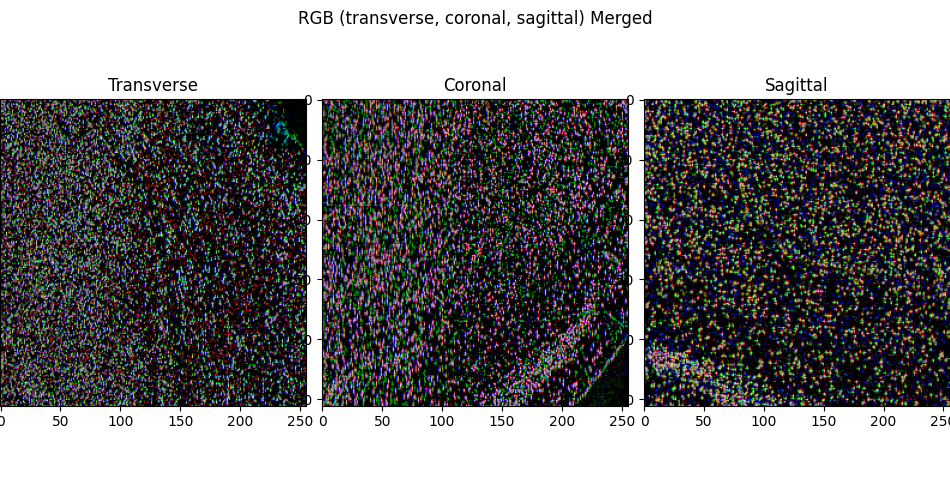

In [79]:
fig,ax = plt.subplots(1,3,figsize=(9.5,5))
ax[0].imshow(np.stack((
    ax0combinedetects[ax0combinedetects.shape[0]//2,...,4],
    ax1combinedetects[ax0combinedetects.shape[0]//2,...,4],
    ax2combinedetects[ax0combinedetects.shape[0]//2,...,4],
),-1),vmin=0,vmax=1)
ax[0].set_title('Transverse')

ax[1].imshow(np.stack((
    ax0combinedetects[:,ax0combinedetects.shape[1]//2,...,4],
    ax1combinedetects[:,ax0combinedetects.shape[1]//2,...,4],
    ax2combinedetects[:,ax0combinedetects.shape[1]//2,...,4],
),-1),vmin=0,vmax=1)
ax[1].set_title('Coronal')

ax[2].imshow(np.stack((
    ax0combinedetects[:,:,ax0combinedetects.shape[2]//2,...,4],
    ax1combinedetects[:,:,ax0combinedetects.shape[2]//2,...,4],
    ax2combinedetects[:,:,ax0combinedetects.shape[2]//2,...,4],
),-1),vmin=0,vmax=1)
ax[2].set_title('Sagittal')


fig.suptitle('RGB (transverse, coronal, sagittal) Merged')
fig.subplots_adjust(left=0,right=1,wspace=0.05)

## (1.2) Combine the three views using minimum (for bbox probability), average (for feature maps), and min/max (for bbox features)
The minimum means the probability must exceed some threshold in all three views

In [93]:
# Initialize the data cube
datacubenew = np.zeros(ax1combinedetects.shape[:3]+(10,)) # 6 for xyzminmax, 1 prob, 3 features

# Update confidence values at every voxel using the minimum probability
datacubenew[...,6] = np.min(np.stack((ax0combinedetects[...,4],ax1combinedetects[...,4],ax2combinedetects[...,4])),0)

# Update the feature labels at every voxel using the avg value
for i in range(3):
    datacubenew[...,7+i] = (ax0combinedetects[...,5+i] + ax1combinedetects[...,5+i] + ax2combinedetects[...,5+i])/3

# Update the bbox features using min for xmin/ymin/zmin, and max for xmax/ymax/zmax
datacubenew[...,0] = np.minimum( ax1combinedetects[...,1], ax2combinedetects[...,1] )  
datacubenew[...,3] = np.maximum( ax1combinedetects[...,3], ax2combinedetects[...,3] )  

# the 1 coordinate (row)
# this is ax0 the 1th coordinate
# and ax2 the 0th coordinate
datacubenew[...,1] = np.minimum( ax0combinedetects[...,1], ax2combinedetects[...,0] )  
datacubenew[...,4] = np.maximum( ax0combinedetects[...,3], ax2combinedetects[...,2] )  

# the 2 coordinate (col)
# this is ax0 the 0th coordinate
# and ax1 the 0th coordinate
datacubenew[...,2] = np.minimum( ax0combinedetects[...,0], ax1combinedetects[...,0] )  
datacubenew[...,5] = np.maximum( ax0combinedetects[...,2], ax1combinedetects[...,2] )

### Generate + save the output

In [ ]:
outname = join(threeDcubedir_for_outputs,f'i{i:04d}_j{j:04d}_k{k:04d}_d{d}_Ex_488_Em_525.npy')
datacubeoutput = datacubenew.copy()

# change from 012012 to 001122 (xmin, ymin, zmin, xmax, ymax, zmax) to (xmin, xmax, ymin, ymax, zmin, zmax)
permutation = [0,3,1,4,2,5]
datacubeoutput[...,:6] = datacubenew[...,permutation]

np.save(outname, datacubeoutput)

### Generate Validation Figures

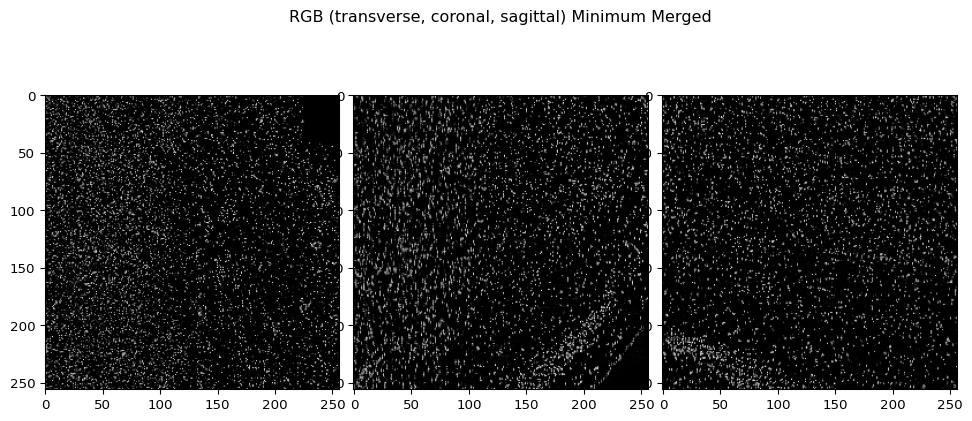

In [7]:
# Plot the confidence values from each view as RGB values (White = bbox w high probability in all 3 views)
fig,ax = plt.subplots(1,3,figsize=(9.5,5))
ax[0].imshow( datacubenew[ax0combinedetects.shape[0]//2,...,6],cmap='gray')
ax[1].imshow( datacubenew[:,ax0combinedetects.shape[1]//2,...,6],cmap='gray')
ax[2].imshow( datacubenew[:,:,ax0combinedetects.shape[2]//2,...,6],cmap='gray')

fig.suptitle('RGB (transverse, coronal, sagittal) Minimum Merged')
fig.subplots_adjust(left=0,right=1,wspace=0.05)

Text(0.5, 1.0, 'single slice (sagittal)')

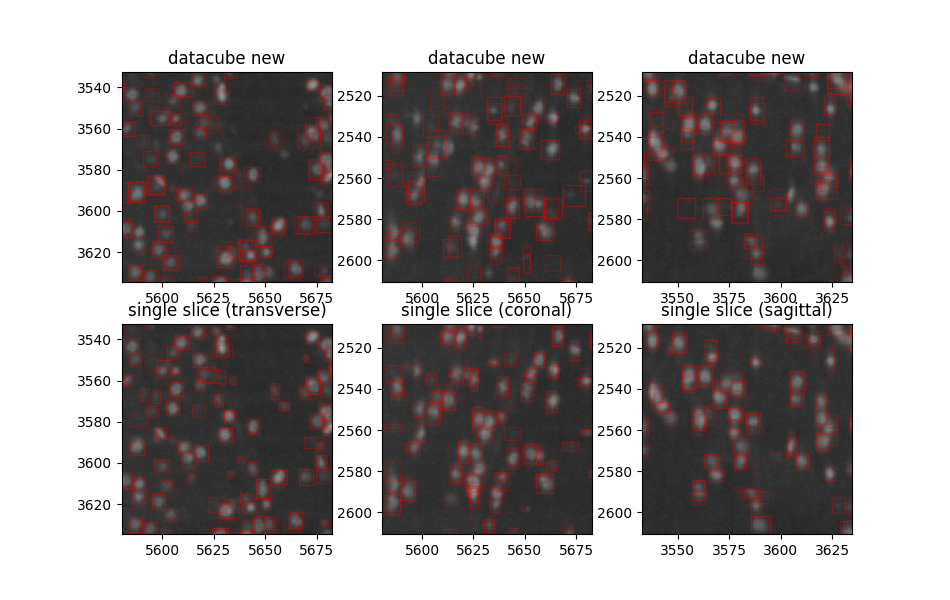

In [94]:
# from these I can now build some rectangles
# use the same code as above

gamma = 0.5


extenthighres0z,extenthighres1z,extenthighres2z = extent_from_x([xhighres[0][int(start0):int(end0)],xhighres[1][int(start1):int(end1)],xhighres[2][int(start2):int(end2)]])    
fig,ax_ = plt.subplots(2,3,figsize=(9.5,6))

################################################################################
# now I want to show the 3d one and all the others
# the cube, transverse slice
ax = ax_[0,0]
sl = datacubenew.shape[0]//2
ax.imshow(datacubenew[sl,...,6], vmin=0,vmax=1,extent=extent_datacube_0)
ax.imshow(Islice[int(start1):int(end1),int(start2):int(end2)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres0z,cmap='gray')
ax.set_title('datacube new')
ax.set_xlim(start2_,end2_)
ax.set_ylim(end1_,start1_)
sliceclose = 4
#sliceclose = 16
#sliceclose = 1
offset = 0
inds = datacubenew[...,6]>0
inds = inds * (np.abs(xdatacube[0] - xdatacube[0][sl+offset]) <= sliceclose )[...,None,None] # everything close to this slice

# TODO
# check if boxes intersect this plane.  Not sliceclose
thresh = 0.25
inds = datacubenew[...,6]>thresh
inds = inds * (datacubenew[...,0]-0.5 <=  xdatacube[0][sl+offset] ) * (datacubenew[...,3]+0.5 >=  xdatacube[0][sl+offset] ) 


# new data cube is in 012,012 order
# I want to fix 0, and plot in order (2,1)
rectdata = np.stack( 
        (
            np.stack((datacubenew[inds,2].ravel(), datacubenew[inds,1].ravel()),-1), 
            np.stack((datacubenew[inds,2].ravel(), datacubenew[inds,4].ravel()),-1),
            np.stack((datacubenew[inds,5].ravel(), datacubenew[inds,4].ravel()),-1), 
            np.stack((datacubenew[inds,5].ravel(), datacubenew[inds,1].ravel()),-1),             
        ),
        1)

edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0

edgecolor[:,-1] = datacubenew[inds,6]*0.5
#edgecolor[:,-1] = 1.0
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=datacubenew[inds,6].ravel(),
    linewidth=1,
)
ax.add_collection(rects)




################################################################################
# the slice
# the transverse slice
ax = ax_[1,0]
ax.imshow(ax0detects[...,4],vmin=0,vmax=1,extent=extentax00)

# rects for the slice
inds = ax0detects[...,4]>0.25 #
# but I also want to restrict the field of view. this will make it much faster
inds = inds * (ax0x1[...,None] >= start1)
inds = inds * (ax0x1[...,None] <= end1)
inds = inds * (ax0x2 >= start2)
inds = inds * (ax0x2 <= end2)
rectdata = np.stack( 
        (
            np.stack((ax0detects[inds,0].ravel(), ax0detects[inds,1].ravel()),-1), 
            np.stack((ax0detects[inds,0].ravel(), ax0detects[inds,3].ravel()),-1),
            np.stack((ax0detects[inds,2].ravel(), ax0detects[inds,3].ravel()),-1), 
            np.stack((ax0detects[inds,2].ravel(), ax0detects[inds,1].ravel()),-1),             
        ),
        1)
edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0
edgecolor[:,-1] = ax0detects[inds,4]*0.5
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=ax0detects[inds,4].ravel(),
    linewidth=1,
)


ax.imshow(Islice[int(start1):int(end1),int(start2):int(end2)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres0z,cmap='gray')
ax.add_collection(rects)
ax.set_xlim(start2_,end2_)
ax.set_ylim(end1_,start1_)
ax.set_title('single slice (transverse)')




################################################################################
# the cube
# the coronal slice
ax = ax_[0,1]
sl = datacubenew.shape[1]//2
ax.imshow(datacubenew[:,sl,...,6], vmin=0,vmax=1,extent=extent_datacube_0)
ax.imshow(Irow[int(start0):int(end0),int(start2):int(end2)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres1z,cmap='gray')
ax.set_title('datacube new')
ax.set_xlim(start2_,end2_)
ax.set_ylim(end0_,start0_)
sliceclose = 4
#sliceclose = 16
#sliceclose = 1
offset = 0
inds = datacubenew[...,6]>0
inds = inds * (np.abs(xdatacube[1] - xdatacube[1][sl+offset]) <= sliceclose )[...,None,None] # everything close to this slice

# TODO
# check if boxes intersect this plane.  Not sliceclose
thresh = 0.25
inds = datacubenew[...,6]>thresh
inds = inds * (datacubenew[...,1]-0.5 <=  xdatacube[1][sl+offset] ) * (datacubenew[...,4]+0.5 >=  xdatacube[1][sl+offset] ) 


# new data cube is in 012,012 order
# I want to fix 0, and plot in order (2,1)
rectdata = np.stack( 
        (
            np.stack((datacubenew[inds,2].ravel(), datacubenew[inds,0].ravel()),-1), 
            np.stack((datacubenew[inds,2].ravel(), datacubenew[inds,3].ravel()),-1),
            np.stack((datacubenew[inds,5].ravel(), datacubenew[inds,3].ravel()),-1), 
            np.stack((datacubenew[inds,5].ravel(), datacubenew[inds,0].ravel()),-1),             
        ),
        1)

edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0

edgecolor[:,-1] = datacubenew[inds,6]*0.5
#edgecolor[:,-1] = 1.0
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=datacubenew[inds,6].ravel(),
    linewidth=1,
)
ax.add_collection(rects)






################################################################################
# the slice
# coronal
ax = ax_[1,1]
ax.imshow(ax1detects[...,4],vmin=0,vmax=1,extent=extentax11)

# rects for the slice
inds = ax1detects[...,4]>0.25 #
# but I also want to restrict the field of view. this will make it much faster
inds = inds * (ax1x0[...,None] >= start0)
inds = inds * (ax1x0[...,None] <= end0)
inds = inds * (ax1x2 >= start2)
inds = inds * (ax1x2 <= end2)
rectdata = np.stack( 
        (
            np.stack((ax1detects[inds,0].ravel(), ax1detects[inds,1].ravel()),-1), 
            np.stack((ax1detects[inds,0].ravel(), ax1detects[inds,3].ravel()),-1),
            np.stack((ax1detects[inds,2].ravel(), ax1detects[inds,3].ravel()),-1), 
            np.stack((ax1detects[inds,2].ravel(), ax1detects[inds,1].ravel()),-1),             
        ),
        1)
edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0
edgecolor[:,-1] = ax1detects[inds,4]*0.5
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=ax0detects[inds,4].ravel(),
    linewidth=1,
)


ax.imshow(Irow[int(start0):int(end0),int(start2):int(end2)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres1z,cmap='gray')
ax.add_collection(rects)
ax.set_xlim(start2_,end2_)
ax.set_ylim(end0_,start0_)
ax.set_title('single slice (coronal)')









################################################################################
# the cube
# the sagittal slice
ax = ax_[0,2]
sl = datacubenew.shape[2]//2
ax.imshow(datacubenew[:,:,sl,...,6], vmin=0,vmax=1,extent=extent_datacube_0)
ax.imshow(Icol[int(start0):int(end0),int(start1):int(end1)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres2z,cmap='gray')
ax.set_title('datacube new')
ax.set_xlim(start1_,end1_)
ax.set_ylim(end0_,start0_)
sliceclose = 4
#sliceclose = 16
#sliceclose = 1
offset = 0
inds = datacubenew[...,6]>0
inds = inds * (np.abs(xdatacube[2] - xdatacube[2][sl+offset]) <= sliceclose )[...,None,None] # everything close to this slice

# TODO
# check if boxes intersect this plane.  Not sliceclose
thresh = 0.25
inds = datacubenew[...,6]>thresh
inds = inds * (datacubenew[...,2]-0.5 <=  xdatacube[2][sl+offset] ) * (datacubenew[...,5]+0.5 >=  xdatacube[2][sl+offset] ) 


# new data cube is in 012,012 order
# I want to fix 0, and plot in order (2,1)
rectdata = np.stack( 
        (
            np.stack((datacubenew[inds,1].ravel(), datacubenew[inds,0].ravel()),-1), 
            np.stack((datacubenew[inds,1].ravel(), datacubenew[inds,3].ravel()),-1),
            np.stack((datacubenew[inds,4].ravel(), datacubenew[inds,3].ravel()),-1), 
            np.stack((datacubenew[inds,4].ravel(), datacubenew[inds,0].ravel()),-1),             
        ),
        1)

edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0

edgecolor[:,-1] = datacubenew[inds,6]*0.5
#edgecolor[:,-1] = 1.0
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=datacubenew[inds,6].ravel(),
    linewidth=1,
)
ax.add_collection(rects)






################################################################################
# the slice
# coronal
ax = ax_[1,2]
ax.imshow(ax2detects[...,4],vmin=0,vmax=1,extent=extentax22)

# rects for the slice
inds = ax2detects[...,4]>0.25 #
# but I also want to restrict the field of view. this will make it much faster
inds = inds * (ax2x0[...,None] >= start0)
inds = inds * (ax2x0[...,None] <= end0)
inds = inds * (ax2x1 >= start1)
inds = inds * (ax2x1 <= end1)
rectdata = np.stack( 
        (
            np.stack((ax2detects[inds,0].ravel(), ax2detects[inds,1].ravel()),-1), 
            np.stack((ax2detects[inds,0].ravel(), ax2detects[inds,3].ravel()),-1),
            np.stack((ax2detects[inds,2].ravel(), ax2detects[inds,3].ravel()),-1), 
            np.stack((ax2detects[inds,2].ravel(), ax2detects[inds,1].ravel()),-1),             
        ),
        1)
edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0
edgecolor[:,-1] = ax2detects[inds,4]*0.5
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=ax0detects[inds,4].ravel(),
    linewidth=1,
)


ax.imshow(Icol[int(start0):int(end0),int(start1):int(end1)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres2z,cmap='gray')
ax.add_collection(rects)
ax.set_xlim(start1_,end1_)
ax.set_ylim(end0_,start0_)
ax.set_title('single slice (sagittal)')




In [102]:
'''
Hi David and Daniel,

Using the convention [x0, x1, y0, y1, z0, z1, conf, ...] for the data stored at each voxel:
- x is along the slice dimension from the original dataset of 3600 coronal slice images. These coordinates are along the Anterior/Posterior axis
- y is the row from those images. These coordinates are along the Inferior/Superior axis
- z is the col from those images. These coordinates are along the L/R axis

Additionally, the images in that screenshot were not rotated for display and are in their original orientation.
'''

'\nHi David and Daniel,\n\nUsing the convention [x0, x1, y0, y1, z0, z1, conf, ...] for the data stored at each voxel:\n- x is along the slice dimension from the original dataset of 3600 coronal slice images. These coordinates are along the Anterior/Posterior axis\n- y is the row from those images. These coordinates are along the Inferior/Superior axis\n- z is the col from those images. These coordinates are along the L/R axis\n\nAdditionally, the images in that screenshot were not rotated for display and are in their original orientation.\n'

# (3) NMS

In [3]:
def compute_iou(data0,data1=None):
    ''' 
    compute iou, uses xyzxyz convention on last axis.
    All leading dimensions keep as is

    Assume we have 2 datasets (the output cubes), data0 and data1
    '''
    if data1 is None:
        data1 = data0

    # get volume of first
    vol0 = ((data0[...,3] - data0[...,0]) * (data0[...,4] - data0[...,1]) * (data0[...,5] - data0[...,2]))[...,:,None]
    vol1 = ((data1[...,3] - data1[...,0]) * (data1[...,4] - data1[...,1]) * (data1[...,5] - data1[...,2]))[...,None,:]
    # Note the fancy indexing - If data0 is size M and data1 is size N, these volumes will be size MxN
    #print(vol0.shape,vol1.shape)
    
    # get volume of intersection
    slice0 = np.maximum( data0[...,0][...,:,None], data1[...,0][...,None,:])
    slice1 = np.minimum( data0[...,3][...,:,None], data1[...,3][...,None,:])
    row0 = np.maximum( data0[...,1][...,:,None], data1[...,1][...,None,:])
    row1 = np.minimum( data0[...,4][...,:,None], data1[...,4][...,None,:])
    col0 = np.maximum( data0[...,2][...,:,None], data1[...,2][...,None,:])
    col1 = np.minimum( data0[...,5][...,:,None], data1[...,5][...,None,:])
    l0 = (slice1-slice0).clip(min=0)
    l1 = (row1-row0).clip(min=0)
    l2 = (col1-col0).clip(min=0)
    intersection = l0*l1*l2
    
    return intersection / (vol0 + vol1 - intersection)

### Load the target cube + Filter by confidence

In [4]:
# NOTE: bb coords are stored in 001122 order in this file, but to run the below code, we expect 012012
fpath = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_3D_outputs_v03/i0002_j0005_k0003_d256_Ex_488_Em_525.npy'
datacubenew = np.load(fpath)

permutation = [0,2,4,1,3,5,6,7,8,9]
datacubenew = datacubenew[...,permutation]
data = datacubenew.copy() # make a copy of our data, so the new one will get edited, without modifying the original

In [6]:
datacubenew[100,100,100]

array([ 2.44684644e+03,  5.51649609e+03,  3.46659399e+03,  2.45345190e+03,
        5.52344287e+03,  3.47565649e+03,  2.22724088e-06,  7.41677523e-01,
       -9.86046016e-01, -1.34215057e+00])

### Apply 'NMS'

In [ ]:
# linear complexity nms
conf_thresh = 0.25 # only consider pixels whose confidence is bigger than this
nms_thresh = 0.25
removed = np.zeros_like(data[...,0],dtype=bool)
r = 5 # chose a radius (+/- to consider neighbors)
for i in range(data.shape[0]): # loop through slice i
    print('.',end='')

    imin = np.clip(i-r,0,data.shape[0]-1)
    imax = np.clip(i+r,0,data.shape[0]-1)
    for j in range(data.shape[1]):  # loop through rows j
        jmin = np.clip(j-r,0,data.shape[1]-1)
        jmax = np.clip(j+r,0,data.shape[1]-1)
        for k  in range(data.shape[2]): # loop through columns k
            thisdata = data[i,j,k]
            # if the confidence at this pixel is less than a threshold, just set it to zero and continu
            if thisdata[6] < conf_thresh:
                removed[i,j,k] = True
                continue
            kmin = np.clip(k-r,0,data.shape[2]-1)
            kmax = np.clip(k+r,0,data.shape[2]-1)

            # cut out a rectangular prism around pixel i,j,k
            cutout = data[imin:imax,jmin:jmax,kmin:kmax]

            # compute pairwise IOU: TODO threshold the cutout so we're only looking at neighbors with higher confidence (not equal or less) so there are less of them, and this step is faster
            iou = compute_iou(thisdata[None],cutout.reshape(-1,cutout.shape[-1])).reshape(cutout.shape[:3]).reshape(cutout.shape[:3])

            # under what situation do we keep this?
            # we keep it if, out of all the ones with iou greater than thresh, this one has the highest prob
            # the candidates to compare with should not be this pixel (i,j,k). if we implement the todo above, the iou < 1 will not be necessary
            candidates = (iou >= nms_thresh)*(iou < 1) # exactly 1 means it is the same one, there should be a better way to exclude
            if not np.any(candidates):
                continue

            # evaluate the confidence on the neighbors
            probs = cutout[candidates][...,6]
            # if none of them are a higher confidence than ijk, we keep ijk
            if thisdata[6] > np.max(probs):
                continue

            # otherwise it's not the biggest among those that overlap, so we remove ijk
            removed[i,j,k] = True

# When writing this out, reverse the permutation from 012012 back to 001122
permutation = [0,3,1,4,2,5,6,7,8,9]
data = data[...,permutation]

print(f'{np.mean(removed)*100:.2f}% of bboxes removed')

In [10]:
# Update the conf of bboxes marked for removal to 0
data[...,6] = np.where(removed,0,data[...,6])

ValueError: supplied range of [-inf, 5.98724365234375] is not finite

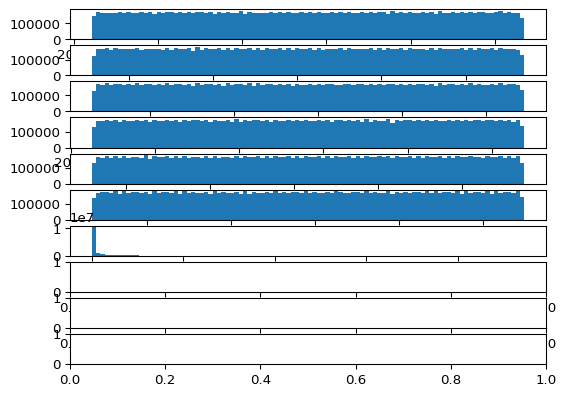

In [28]:
fig, ax = plt.subplots(10,1)

_ = ax[0].hist(datacubenew[...,0].ravel(), 100)
_ = ax[1].hist(datacubenew[...,1].ravel(), 100)
_ = ax[2].hist(datacubenew[...,2].ravel(), 100)
_ = ax[3].hist(datacubenew[...,3].ravel(), 100)
_ = ax[4].hist(datacubenew[...,4].ravel(), 100)
_ = ax[5].hist(datacubenew[...,5].ravel(), 100)
_ = ax[6].hist(datacubenew[...,6].ravel(), 100)
_ = ax[7].hist(datacubenew[...,7].ravel(), 100)
_ = ax[8].hist(datacubenew[...,8].ravel(), 100)
_ = ax[9].hist(datacubenew[...,9].ravel(), 100)


fig.set_size_inches(3,10)

### Initialize data structures used in visualization

In [19]:
# Load the original image files to initialize the coordinate space AND 
raw_image_file_first_two_views = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
vol01 = h5py.File(raw_image_file_first_two_views)
nhighres = vol01['stack'].shape
xhighres = [np.arange(n) for n in nhighres]

raw_image_file_third_view = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_full_sag.h5'
vol2 = h5py.File(raw_image_file_third_view)
nhighres = vol2['stack'].shape

# Define which cube we are looking at
i,j,k,d = 2,5,3,256
ndatacube = np.array((d,d,d)) # The shape of the output cube

# Compute the coordinate offset that results from the 4x downsampling
x0datacube = np.array([0,0,0]) # initialize 
x0datacube = np.array([1.5,1.5,1.5]) + np.array([i,j,k])*d*4 # (up by 2 down by 8)

# Initialize the coordinate space for this specific cube + Extract extents for visualization
xdatacube = [np.arange(n)*4+o for n,o in zip(ndatacube,x0datacube)]
extent_datacube_0, extent_datacube_1 ,extent_datacube_2 = extent_from_x(xdatacube)

# Define the relative voxel size
ddatacube = np.array([4,4,4])

# Initialize the middle idx along each ax
m0 = int( np.round( xdatacube[0][len(xdatacube[0])//2]) )
m1 = int( np.round( xdatacube[1][len(xdatacube[1])//2]) )
m2 = int( np.round( xdatacube[2][len(xdatacube[2])//2]) ) 

# Extract the image data along the middle of each volume
Islice = vol01['stack'][m0]
Irow   = vol01['stack'][:,m1]
Icol = vol2['stack'][:,:,m2]

# Load the OUTPUT DATA in the middle slice along each dimension (Each slice contains bbox info at every pixel)
ax0outputdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax0'
ax0files = glob(os.path.join(ax0outputdir,'*.npy'))
ax0files.sort()
ax0detects = np.load(ax0files[m0]) # this is the middle slice

ax1outputdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax1'
ax1files = glob(os.path.join(ax1outputdir,'*.npy'))
ax1files.sort()
ax1detects = np.load(ax1files[m1])

ax2outputdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax2'
ax2files = glob(os.path.join(ax2outputdir,'*.npy'))
ax2files.sort()
ax2detects = np.load(ax2files[m2])

# Extract the start and end coordiantes along each axis
start0 = xdatacube[0][0]
start1 = xdatacube[1][0]
start2 = xdatacube[2][0]

end0 = xdatacube[0][-1]
end1 = xdatacube[1][-1]
end2 = xdatacube[2][-1]

# Define the start + end indeces for a ZOOMED window
zoom = 1/10
start0_,end0_ = (start0+end0)/2 - (end0-start0)/2*zoom, (start0+end0)/2 + (end0-start0)/2*zoom
start1_,end1_ = (start1+end1)/2 - (end1-start1)/2*zoom, (start1+end1)/2 + (end1-start1)/2*zoom
start2_,end2_ = (start2+end2)/2 - (end2-start2)/2*zoom, (start2+end2)/2 + (end2-start2)/2*zoom

# Initialize more extents?
ax0x1 = np.arange(ax0detects.shape[0])*4 + np.mean( np.array([0,1,2,3]) )
ax0x2 = np.arange(ax0detects.shape[1])*4 + np.mean( np.array([0,1,2,3]) )
ax0x = [ax0x1,ax0x2]
extentax00,extentax01,extentax02 = extent_from_x([[0,1],ax0x1,ax0x2])

ax1x0 = np.arange(ax1detects.shape[0])*4 + np.mean( np.array([0,1,2,3]) )
ax1x2 = np.arange(ax1detects.shape[1])*4 + np.mean( np.array([0,1,2,3]) )
ax1x = [ax1x0,ax1x2]
extentax10,extentax11,extentax12 = extent_from_x([ax1x0,[0,1],ax1x2])

ax2x0 = np.arange(ax2detects.shape[0])*4 + np.mean( np.array([0,1,2,3]) )
ax2x1 = np.arange(ax2detects.shape[1])*4 + np.mean( np.array([0,1,2,3]) )
ax2x = [ax2x0,ax2x1]
extentax20,extentax21,extentax22 = extent_from_x([ax2x0,ax2x1,[0,1],])

### Generate the main visualization

Exception: 

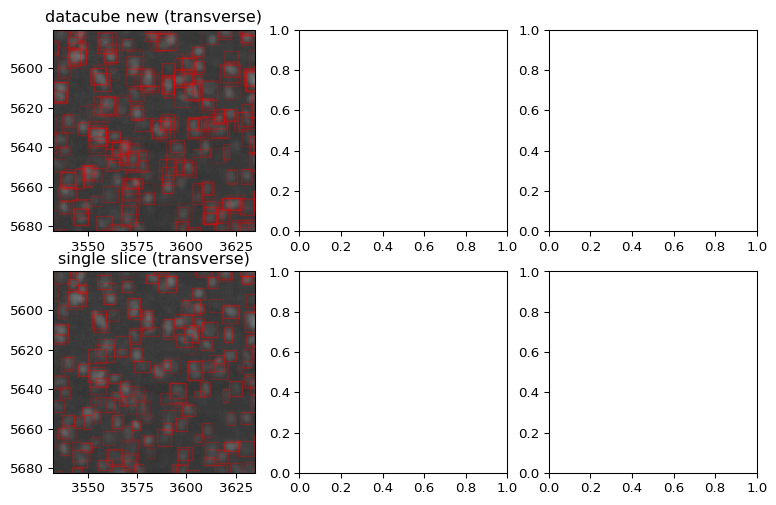

In [29]:
# from these I can now build some rectangles
# use the same code as above
gamma = 0.5

data = datacubenew.copy() # make a copy of our data, so the new one will get edited, without modifying the original

extenthighres0z,extenthighres1z,extenthighres2z = extent_from_x([xhighres[0][int(start0):int(end0)],xhighres[1][int(start1):int(end1)],xhighres[2][int(start2):int(end2)]])    
fig,ax_ = plt.subplots(2,3,figsize=(9.5,6))

# =================================
# ===== THE CUBE - Transverse =====
# =================================
ax = ax_[0,0]
sl = data.shape[0]//2
ax.imshow(data[sl,...,6], vmin=0,vmax=1,extent=extent_datacube_0)
ax.imshow(Islice[int(start1):int(end1),int(start2):int(end2)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres0z,cmap='gray')
ax.set_title('datacube new (transverse)')
ax.set_xlim(start2_,end2_)
ax.set_ylim(end1_,start1_)
sliceclose = 4
offset = 0
inds = data[...,6]>0
inds = inds * (np.abs(xdatacube[0] - xdatacube[0][sl+offset]) <= sliceclose )[...,None,None] # everything close to this slice

# TODO
# check if boxes intersect this plane.  Not sliceclose
thresh = 0.25
inds = data[...,6]>thresh
inds = inds * (data[...,0]-0.5 <=  xdatacube[0][sl+offset] ) * (data[...,3]+0.5 >=  xdatacube[0][sl+offset] ) 


# new data cube is in 012,012 order
# I want to fix 0, and plot in order (2,1)
rectdata = np.stack( 
        (
            np.stack((data[inds,2].ravel(), data[inds,1].ravel()),-1), 
            np.stack((data[inds,2].ravel(), data[inds,4].ravel()),-1),
            np.stack((data[inds,5].ravel(), data[inds,4].ravel()),-1), 
            np.stack((data[inds,5].ravel(), data[inds,1].ravel()),-1),             
        ),
        1)

edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0

edgecolor[:,-1] = data[inds,6]*0.5
#edgecolor[:,-1] = 1.0
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=data[inds,6].ravel(),
    linewidth=1,
)
ax.add_collection(rects)

# ==================================
# ===== THE SLICE - Transverse =====
# ==================================
ax = ax_[1,0]
ax.imshow(ax0detects[...,4],vmin=0,vmax=1,extent=extentax00)

# rects for the slice
inds = ax0detects[...,4]>0.25 #
# but I also want to restrict the field of view. this will make it much faster
inds = inds * (ax0x1[...,None] >= start1)
inds = inds * (ax0x1[...,None] <= end1)
inds = inds * (ax0x2 >= start2)
inds = inds * (ax0x2 <= end2)
rectdata = np.stack( 
        (
            np.stack((ax0detects[inds,0].ravel(), ax0detects[inds,1].ravel()),-1), 
            np.stack((ax0detects[inds,0].ravel(), ax0detects[inds,3].ravel()),-1),
            np.stack((ax0detects[inds,2].ravel(), ax0detects[inds,3].ravel()),-1), 
            np.stack((ax0detects[inds,2].ravel(), ax0detects[inds,1].ravel()),-1),             
        ),
        1)
edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0
edgecolor[:,-1] = ax0detects[inds,4]*0.5
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=ax0detects[inds,4].ravel(),
    linewidth=1,
)


ax.imshow(Islice[int(start1):int(end1),int(start2):int(end2)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres0z,cmap='gray')
ax.add_collection(rects)
ax.set_xlim(start2_,end2_)
ax.set_ylim(end1_,start1_)
ax.set_title('single slice (transverse)')


raise Exception

# ==============================
# ===== THE CUBE - Coronal =====
# ==============================
ax = ax_[0,1]
sl = data.shape[1]//2
ax.imshow(data[:,sl,...,6], vmin=0,vmax=1,extent=extent_datacube_0)
ax.imshow(Irow[int(start0):int(end0),int(start2):int(end2)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres1z,cmap='gray')
ax.set_title('datacube new (Coronal)')
ax.set_xlim(start2_,end2_)
ax.set_ylim(end0_,start0_)
sliceclose = 4
#sliceclose = 16
#sliceclose = 1
offset = 0
inds = data[...,6]>0
inds = inds * (np.abs(xdatacube[1] - xdatacube[1][sl+offset]) <= sliceclose )[...,None,None] # everything close to this slice

# TODO
# check if boxes intersect this plane.  Not sliceclose
thresh = 0.25
inds = data[...,6]>thresh
inds = inds * (data[...,1]-0.5 <=  xdatacube[1][sl+offset] ) * (data[...,4]+0.5 >=  xdatacube[1][sl+offset] ) 


# new data cube is in 012,012 order
# I want to fix 0, and plot in order (2,1)
rectdata = np.stack( 
        (
            np.stack((data[inds,2].ravel(), data[inds,0].ravel()),-1), 
            np.stack((data[inds,2].ravel(), data[inds,3].ravel()),-1),
            np.stack((data[inds,5].ravel(), data[inds,3].ravel()),-1), 
            np.stack((data[inds,5].ravel(), data[inds,0].ravel()),-1),             
        ),
        1)

edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0

edgecolor[:,-1] = data[inds,6]*0.5
#edgecolor[:,-1] = 1.0
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=data[inds,6].ravel(),
    linewidth=1,
)
ax.add_collection(rects)


# ==============================
# ===== THE SLICE - Coronal =====
# ==============================
ax = ax_[1,1]
ax.imshow(ax1detects[...,4],vmin=0,vmax=1,extent=extentax11)

# rects for the slice
inds = ax1detects[...,4]>0.25 #
# but I also want to restrict the field of view. this will make it much faster
inds = inds * (ax1x0[...,None] >= start0)
inds = inds * (ax1x0[...,None] <= end0)
inds = inds * (ax1x2 >= start2)
inds = inds * (ax1x2 <= end2)
rectdata = np.stack( 
        (
            np.stack((ax1detects[inds,0].ravel(), ax1detects[inds,1].ravel()),-1), 
            np.stack((ax1detects[inds,0].ravel(), ax1detects[inds,3].ravel()),-1),
            np.stack((ax1detects[inds,2].ravel(), ax1detects[inds,3].ravel()),-1), 
            np.stack((ax1detects[inds,2].ravel(), ax1detects[inds,1].ravel()),-1),             
        ),
        1)
edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0
edgecolor[:,-1] = ax1detects[inds,4]*0.5
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=ax0detects[inds,4].ravel(),
    linewidth=1,
)


ax.imshow(Irow[int(start0):int(end0),int(start2):int(end2)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres1z,cmap='gray')
ax.add_collection(rects)
ax.set_xlim(start2_,end2_)
ax.set_ylim(end0_,start0_)
ax.set_title('single slice (coronal)')

# ===============================
# ===== THE CUBE - Sagittal =====
# ===============================
ax = ax_[0,2]
sl = data.shape[2]//2
ax.imshow(data[:,:,sl,...,6], vmin=0,vmax=1,extent=extent_datacube_0)
ax.imshow(Icol[int(start0):int(end0),int(start1):int(end1)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres2z,cmap='gray')
ax.set_title('datacube new (Sagittal)')
ax.set_xlim(start1_,end1_)
ax.set_ylim(end0_,start0_)
sliceclose = 4
#sliceclose = 16
#sliceclose = 1
offset = 0
inds = data[...,6]>0
inds = inds * (np.abs(xdatacube[2] - xdatacube[2][sl+offset]) <= sliceclose )[...,None,None] # everything close to this slice

# TODO
# check if boxes intersect this plane.  Not sliceclose
thresh = 0.25
inds = data[...,6]>thresh
inds = inds * (data[...,2]-0.5 <=  xdatacube[2][sl+offset] ) * (data[...,5]+0.5 >=  xdatacube[2][sl+offset] ) 


# new data cube is in 012,012 order
# I want to fix 0, and plot in order (2,1)
rectdata = np.stack( 
        (
            np.stack((data[inds,1].ravel(), data[inds,0].ravel()),-1), 
            np.stack((data[inds,1].ravel(), data[inds,3].ravel()),-1),
            np.stack((data[inds,4].ravel(), data[inds,3].ravel()),-1), 
            np.stack((data[inds,4].ravel(), data[inds,0].ravel()),-1),             
        ),
        1)

edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0

edgecolor[:,-1] = data[inds,6]*0.5
#edgecolor[:,-1] = 1.0
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=data[inds,6].ravel(),
    linewidth=1,
)
ax.add_collection(rects)

# ================================
# ===== THE SLICE - Sagittal =====
# ================================
ax = ax_[1,2]
ax.imshow(ax2detects[...,4],vmin=0,vmax=1,extent=extentax22)

# rects for the slice
inds = ax2detects[...,4]>0.25 #
# but I also want to restrict the field of view. this will make it much faster
inds = inds * (ax2x0[...,None] >= start0)
inds = inds * (ax2x0[...,None] <= end0)
inds = inds * (ax2x1 >= start1)
inds = inds * (ax2x1 <= end1)
rectdata = np.stack( 
        (
            np.stack((ax2detects[inds,0].ravel(), ax2detects[inds,1].ravel()),-1), 
            np.stack((ax2detects[inds,0].ravel(), ax2detects[inds,3].ravel()),-1),
            np.stack((ax2detects[inds,2].ravel(), ax2detects[inds,3].ravel()),-1), 
            np.stack((ax2detects[inds,2].ravel(), ax2detects[inds,1].ravel()),-1),             
        ),
        1)
edgecolor = np.zeros((len(rectdata),4))
edgecolor[:,0] = 1.0
edgecolor[:,-1] = ax2detects[inds,4]*0.5
rects = matplotlib.collections.PolyCollection(    
    rectdata, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolor,
    #alpha=ax0detects[inds,4].ravel(),
    linewidth=1,
)


ax.imshow(Icol[int(start0):int(end0),int(start1):int(end1)]**gamma,vmin=0,vmax=(65535/4)**gamma,extent=extenthighres2z,cmap='gray')
ax.add_collection(rects)
ax.set_xlim(start1_,end1_)
ax.set_ylim(end0_,start0_)
ax.set_title('single slice (sagittal)')

# next write it out
Alsoo, when we do nms we have to make sure we do it properly at boundaries.  This will likely mean reloading the data.

In [ ]:
# let's check some stuff
fig,ax = plt.subplots(2,3)
ax[0,0].hist(datacubenew[...,0].ravel())
# 0 goes from about 2000 to about 3000
# this is the 0th index
ax[0,1].hist(datacubenew[...,1].ravel())
# 1 is the same, 0th index
ax[0,2].hist(datacubenew[...,2].ravel())
# the 2 index goes from 3000 to 4000
# this is the 1th coordinate
ax[1,0].hist(datacubenew[...,3].ravel())
# last ones
ax[1,1].hist(datacubenew[...,4].ravel())
ax[1,2].hist(datacubenew[...,5].ravel())

In [ ]:
# so what should my nms be?
# input a list with 7 numbers (last one is prob)
# output a list of probs, with overlapping ones set to zero

In [ ]:
raise Exception('no more')

In [ ]:
# d the same with the datacube
fig,ax = plt.subplots()
ax.imshow(np.stack((
    datacube[ax0combinedetects.shape[0]//2,...,6],
    datacube[ax0combinedetects.shape[0]//2,...,6],
    datacube[ax0combinedetects.shape[0]//2,...,4],
),-1),vmin=0,vmax=1)
ax.set_title('RGB (transverse, coronal, sagittal) Merged')


In [ ]:
# note these three are in the order xyxy
# 

In [ ]:
raise Exception('no more')

In [ ]:
# these ones are maxpooled by a factor of 4, along their respective slice dimensions
# extents are averaged, but ideally they will be minmaxed
ax0downoutputdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax0_down'
ax1downoutputdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax1_down'
ax2downoutputdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax2_down'

In [ ]:
m0

In [ ]:
glob(join(ax0outputdir,'*'))

In [ ]:
ax0detectsdown = np.load( '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax0_down/Ex_488_Em_525_stitched_chunk32_ax0_02560:02563.npy',)

In [ ]:
ax0detectsdownp =  ax0detectsdown[...,4] 

In [ ]:
# now I want to show the 3d one
# 
fig,ax_ = plt.subplots(1,3)
ax = ax_[0]
ax.imshow(datacube[datacube.shape[0]//2,...,6], vmin=0,vmax=1,extent=extent_datacube_0)
#ax.imshow(Islice,vmin=0,vmax=65535,extent=extenthighres0)
ax.set_title('datacube')
ax.set_xlim(start2,end2)
ax.set_ylim(end1,start1)




ax = ax_[1]
ax.imshow(ax0p,vmin=0,vmax=1,extent=extentax00)
#ax.imshow(Islice,vmin=0,vmax=65535,extent=extenthighres0)
#ax.add_collection(rects)
ax.set_xlim(start2,end2)
ax.set_ylim(end1,start1)
ax.set_title('single slice')

ax = ax_[2]
ax.imshow(ax0detectsdownp,vmin=0,vmax=1,extent=extentax00)
#ax.imshow(Islice,vmin=0,vmax=65535,extent=extenthighres0)
#ax.add_collection(rects)
ax.set_xlim(start2,end2)
ax.set_ylim(end1,start1)
ax.set_title('4x merged slice')

In [ ]:
plt.close('all')

In [ ]:
# repeat by drawing the rects
# 

In [ ]:
rectdatacube = np.stack( 
        (
            np.stack((datacube[datacube.shape[0]//2,...,0].ravel(), datacube[datacube.shape[0]//2,...,1].ravel()),-1), 
            np.stack((datacube[datacube.shape[0]//2,...,0].ravel(), datacube[datacube.shape[0]//2,...,4].ravel()),-1),
            np.stack((datacube[datacube.shape[0]//2,...,3].ravel(), datacube[datacube.shape[0]//2,...,4].ravel()),-1), 
            np.stack((datacube[datacube.shape[0]//2,...,3].ravel(), datacube[datacube.shape[0]//2,...,1].ravel()),-1),             
        ),
        1)
edgecolordatacube = np.zeros((len(rectdatacube),4))
edgecolordatacube[:,0] = 1.0
edgecolordatacube[:,-1] = datacube[datacube.shape[0]//2,...,6].ravel()*0.5
rectsdatacube = matplotlib.collections.PolyCollection(    
    rectdatacube, # divide by 4 to account for scale change
    facecolor='none',
    edgecolor=edgecolordatacube,
    #alpha=ax0detects[inds,4].ravel(),
)

fig,ax_ = plt.subplots(1,3)
ax = ax_[0]
ax.imshow(datacube[datacube.shape[0]//2,...,6], vmin=0,vmax=1,extent=extent_datacube_0)
#ax.imshow(Islice,vmin=0,vmax=65535,extent=extenthighres0)
ax.set_title('datacube')
ax.set_xlim(start2,end2)
ax.set_ylim(end1,start1)
ax.add_collection(rectsdatacube)

In [ ]:
rectdatacube

In [ ]:
# okay so what's my plan?
# let's extract the cube

In [ ]:
np.arange(start1,end1,4)

In [ ]:
datacube.shape

In [ ]:
# so what if I wanted to stitch this myself
# 